# Simulation of the Yokogawa CSU-10 spinning disk

In [1]:
import numpy as np
from scipy.signal import fftconvolve
import matplotlib.pyplot as plt
import matplotlib.animation as animation

# Nipkow disk models

In [3]:
class NipkowDiskNaive:
    """ Nipkow disk model for the Yokogawa CSU-10 spinning disk confocal microscope.
    Distance between pinholes is erregular because of the constant angular step along the Archimedean spiral,
    but the overall pattern is symmetric with 12 sectors.
    
    """
    
    def __init__(self, r_in_mm=30.0, r_out_mm=50.0,
                 num_pinholes=20000,
                 sectors=12, revolution_per_sector=2):
        self.r_in = r_in_mm
        self.r_out = r_out_mm
        self.total_pinholes = num_pinholes
        self.sectors = sectors
        self.revolution_per_sector = revolution_per_sector
        self.r, self.theta = self._generate_geometry()

    def _generate_geometry(self):
        """Generation of the disk model in polar coordinates (r, theta) for all pinholes.
        The pinholes are distributed in 12 sectors, each following an Archimedean spiral.
        
        """
        pts_per_sector = self.total_pinholes // self.sectors
        print(f"Generated {pts_per_sector} pinholes per sector, total {self.total_pinholes} pinholes.")
        
        # Basis of the Archimedean spiral for one sector
        r_base = np.linspace(self.r_in, self.r_out, pts_per_sector)
        theta_base = np.linspace(0, (2 * self.revolution_per_sector) * np.pi, pts_per_sector)
        print(f"Angle step per pinhole {theta_base[1] - theta_base[0]:.4f} radians or {(theta_base[1] - theta_base[0]) * 180 / np.pi:.2f} degrees.") 
        
        # 12 sectors with angular offsets
        r_all = np.tile(r_base, self.sectors)
        offsets = np.repeat(np.linspace(0, 2 * np.pi, self.sectors, endpoint=False), pts_per_sector)
        theta_all = np.tile(theta_base, self.sectors) + offsets
        
        return r_all, theta_all % (2 * np.pi)

    def plot(self):
        """Disk model visualization.
        
        """
        plt.figure(figsize=(10, 10))
        plt.scatter(self.r * np.cos(self.theta), self.r * np.sin(self.theta), s=0.05, c='k'); plt.axis('equal')
        plt.axis('off')
        plt.show()

In [4]:
class NipkowDisk():
    """ Nipkow disk model for the Yokogawa CSU-10 spinning disk confocal microscope.
    Precise model with constant distance between pinholes along the Archimedean spiral,
    achieved by iterative step refinement.
    """
    
    def __init__(self, r_in_mm=30.0, r_out_mm=50.0,
                 num_pinholes=20000, sectors=12,
                 revolution_per_sector=2,
                 pinhole_dist_mm:int=None):
        self.r_in = r_in_mm
        self.r_out = r_out_mm
        self.total_pinholes = num_pinholes
        self.sectors = sectors
        self.revolution_per_sector = revolution_per_sector
        self.pinhole_dist_mm = pinhole_dist_mm
        self.r, self.theta = self._generate_geometry()
        self.r_out = np.max(self.r)

    def _generate_geometry(self):
        pts_per_sector = self.total_pinholes // self.sectors
        print(f"Generated {pts_per_sector} pinholes per sector, total {self.total_pinholes} pinholes.")
    

        if self.pinhole_dist_mm is not None:
            d_ref = self.pinhole_dist_mm
            print(f"Using user-defined pinhole distance: {d_ref:.4f} mm.")
        else:
            # Calculation of the reference distance at the outer edge of the original spiral model
            d_theta_orig = (2 * self.revolution_per_sector) * np.pi / (pts_per_sector - 1)
            d_r_orig = (self.r_out - self.r_in) / (pts_per_sector - 1)
            
            r1, theta1 = self.r_out, 2 * np.pi
            r2, theta2 = self.r_out - d_r_orig, 2 * np.pi - d_theta_orig
        
            x1, y1 = r1 * np.cos(theta1), r1 * np.sin(theta1)
            x2, y2 = r2 * np.cos(theta2), r2 * np.sin(theta2)
            d_ref = np.sqrt((x1 - x2)**2 + (y1 - y2)**2)
        print(f"Reference distance between pinholes at the outer edge: {d_ref:.4f} mm.")

        a = self.r_in
        b = (self.r_out - self.r_in) / (2 * np.pi)
        
        theta_base = [0.0]
        r_base = [a]
        
        current_theta = 0.0
        for _ in range(1, pts_per_sector):
            r_curr = a + b * current_theta
            
            # Initial step approximation (dt ~ ds / r)
            dt = d_ref / np.sqrt(b**2 + r_curr**2)
            
            # Iterative step refinement (cosine law to maintain constant distance d_ref)
            for _ in range(5):
                r_next = a + b * (current_theta + dt)
                cos_val = (r_next**2 + r_curr**2 - d_ref**2) / (2 * r_next * r_curr)
                cos_val = np.clip(cos_val, -1.0, 1.0)
                dt = np.arccos(cos_val)
                
            current_theta += dt
            theta_base.append(current_theta)
            r_base.append(a + b * current_theta)
            
        r_base = np.array(r_base)
        theta_base = np.array(theta_base)
        
        r_all = np.tile(r_base, self.sectors)
        offsets = np.repeat(np.linspace(0, 2 * np.pi, self.sectors, endpoint=False), pts_per_sector)
        theta_all = np.tile(theta_base, self.sectors) + offsets
        
        return r_all, theta_all % (2 * np.pi)
    
    def plot(self):
        """ Disk model visualization.
        
        """
        plt.figure(figsize=(10, 10))
        plt.scatter(self.r * np.cos(self.theta), self.r * np.sin(self.theta), s=0.05, c='k'); plt.axis('equal')
        plt.axis('off')
        plt.show()

In [5]:
class NipkowDiskYokogawa():
    """ Analitical model of the Yokogawa disk based on the Equal pitch spiral pattern.
    Adapted from the original paper Tanaami et al., 2002,'High-speed 1-frame/ms scanning confocal microscope with a microlens and Nipkow disks', https://doi.org/10.1364/AO.41.004704
    
    """
    def __init__(self, r_in_mm=30.0, r_out_mm=50.0, sectors=12, pitch_mm=0.25, min_pinholes=20000):
        self.r_in = r_in_mm
        self.r_out = r_out_mm
        self.sectors = sectors
        self.pitch = pitch_mm
        self.min_pinholes = min_pinholes
        self.r, self.theta = self._generate_geometry()

    def _generate_geometry(self):
        m = self.sectors
        a = self.pitch
        r_o = self.r_in - self.pitch
        
        print(f'Initial R out: {self.r_out}')

        # Pinholes number estimation (кількість апертур, що фізично вміщаються до r_out)
        n_geom = int(np.floor((np.pi * (self.r_out**2 - r_o**2)) / (m * a**2))) + 1
        n_req = int(np.ceil(self.min_pinholes / m))
        
        # Final pinhole number
        n = max(n_geom, n_req)
        self.total_pinholes = n * m
        print(f"Generated {m} sectors, {n} pinholes per sector, total {self.total_pinholes} pinholes")
        
        i = np.arange(n)
        
        # Original equation from Tanaami et al., 2002
        r_base = np.sqrt(r_o**2 + i * m * a**2 / np.pi)
        theta_base = (2 * np.pi / (m * a)) * (r_base - r_o)
        
        r_all = np.tile(r_base, m)
        offsets = np.repeat(np.linspace(0, 2 * np.pi, m, endpoint=False), n)
        theta_all = np.tile(theta_base, m) + offsets
        
        self.r_out = float(np.max(r_all))
        print(f'Final R out: {self.r_out:.2f}')

        return r_all, theta_all % (2 * np.pi)
    
    def plot(self):
        """ Disk model visualization.
        
        """
        plt.figure(figsize=(10, 10))
        plt.scatter(self.r * np.cos(self.theta), self.r * np.sin(self.theta), s=0.05, c='k'); plt.axis('equal')
        plt.axis('off')
        plt.show()

# Acquisition simulation

In [6]:
class CSUSimulator:
    """Acquisition simulator for the Yokogawa CSU-10 spinning disk confocal microscope.
    
    """
    
    def __init__(self, disk: NipkowDisk,
                 fov_center_mm=(40.0, 0.0), fov_size_mm=(10.0, 10.0),
                 camera_res=1000):
        self.disk = disk
        self.fov_center = fov_center_mm
        self.fov_h = fov_size_mm[0]
        self.fov_w = fov_size_mm[1]
        self.camera_res = camera_res
        self.px_size_mm = max(self.fov_w, self.fov_h) / self.camera_res
        self.res_x = int(np.round(self.fov_w / self.px_size_mm))
        self.res_y = int(np.round(self.fov_h / self.px_size_mm))

        # Bounds of the field of view in mm
        self.x_min = self.fov_center[0] - self.fov_w / 2
        self.x_max = self.fov_center[0] + self.fov_w / 2
        self.y_min = self.fov_center[1] - self.fov_h / 2
        self.y_max = self.fov_center[1] + self.fov_h / 2

    def _accumulate_counts(self, start_angle, end_angle):
        arc_len = self.px_size_mm / 2.0
        steps = max(2, int((self.disk.r_out * (end_angle - start_angle)) / arc_len))
        d_theta = np.linspace(start_angle, end_angle, steps)
        theta_t = self.disk.theta[:, None] + d_theta[None, :]
        x, y = self.disk.r[:, None] * np.cos(theta_t), self.disk.r[:, None] * np.sin(theta_t)
        mask = (x >= self.x_min) & (x <= self.x_max) & (y >= self.y_min) & (y <= self.y_max)
        counts, _, _ = np.histogram2d(y[mask], x[mask], bins=[self.res_y, self.res_x], range=[[self.y_min, self.y_max], [self.x_min, self.x_max]])
        return counts

    def _apply_psf(self, img_counts, pinhole_diam_mm):
        ph_px = max(1, int(pinhole_diam_mm / self.px_size_mm))
        grid = np.ogrid[-ph_px:ph_px+1, -ph_px:ph_px+1]
        kernel = (grid[0]**2 + grid[1]**2 <= (ph_px/2)**2).astype(np.uint32)
        return fftconvolve(img_counts, kernel, mode='same')

    def simulate_exposure(self, rpm=1800.0, exposure_sec=0.003, pinhole_diam_mm=0.05, return_raw=False):
        """ Simulate a single exposure.
        
        Parameters:
        - rpm: rotation speed of the disk in revolutions per minute.
        - exposure_sec: duration of the exposure in seconds.
        - pinhole_diam_mm: diameter of the pinholes in millimeters.
        - return_raw: if True, also return the raw counts before PSF application.

        Returns:
        - img_final: the final simulated image after applying the PSF.
        - counts (optional): the raw counts accumulated during the exposure before PSF application.

        """
        counts = self._accumulate_counts(0, (rpm / 60.0) * 2 * np.pi * exposure_sec)
        img_final = self._apply_psf(counts, pinhole_diam_mm)
        return (img_final, counts) if return_raw else img_final

    def simulate_pulse_exposure(self, rpm=1800.0, exposure_sec=0.001, gap_sec=0.002, total_sec=0.01, phase_shift=0.0, pinhole_diam_mm=0.05, return_raw=False):
        """ Simulate a pulsed exposure.

        Parameters:
        - rpm: rotation speed of the disk in revolutions per minute.
        - exposure_sec: duration of each exposure pulse in seconds.
        - gap_sec: time gap between consecutive exposure pulses in seconds.
        - total_sec: total duration of the simulation in seconds.
        - phase_shift: initial time offset of the beginning of the exposure in second.
        - pinhole_diam_mm: diameter of the pinholes in millimeters.
        - return_raw: if True, also return the raw counts before PSF application.

        Returns:
        - img_final: the final simulated image after applying the PSF.
        - counts (optional): the raw counts accumulated during the exposure before PSF application.
        
        """
        omega = (rpm / 60.0) * 2 * np.pi
        total_counts = np.zeros((self.res_y, self.res_x))
        t = phase_shift
        while t < total_sec:
            end_t = min(t + exposure_sec, total_sec)
            total_counts += self._accumulate_counts(omega * t, omega * end_t)
            t += exposure_sec + gap_sec
        img_final = self._apply_psf(total_counts, pinhole_diam_mm)
        return (img_final, total_counts) if return_raw else img_final

    def animate_pulse_exposure(self, rpm=1800.0, rotations=1.0, exposure_sec=0.001, gap_sec=0.002, phase_shift=0.0, pinhole_diam_mm=0.05, filename="csu_simulation.gif", fps=15):
        """ Generate an animation of the pulsed exposure process.
        
        """
        omega = (rpm / 60.0) * 2 * np.pi
        total_sec = rotations * 60.0 / rpm
        
        fig, ax = plt.subplots(figsize=(5, 5 * (self.fov_h / self.fov_w)))
        ax.axis('off')
        ax.set_title(f'Pulse exposure: {(exposure_sec * 1e6):.0f} us, cycle duration: {((gap_sec+exposure_sec) * 1000):.2f} ms, \ntotal rotations: {rotations}, RPM: {rpm}')
        img_plot = ax.imshow(np.zeros((self.res_y, self.res_x)), cmap='inferno', vmin=0, vmax=1)
        
        total_counts = np.zeros((self.res_y, self.res_x))
        times = []
        t = phase_shift
        while t < total_sec:
            times.append(t)
            t += exposure_sec + gap_sec
            
        if not times:
            plt.close(fig)
            return
            
        def update(frame_idx):
            nonlocal total_counts
            t = times[frame_idx]
            end_t = min(t + exposure_sec, total_sec)
            total_counts += self._accumulate_counts(omega * t, omega * end_t)
            
            current_img = self._apply_psf(total_counts, pinhole_diam_mm)
            vmax = np.max(current_img)
            img_plot.set_data(current_img)
            img_plot.set_clim(vmin=0, vmax=vmax if vmax > 0 else 1)
            return [img_plot]
            
        ani = animation.FuncAnimation(fig, update, frames=len(times), blit=True)
        ani.save(filename, writer='pillow', fps=fps, dpi=200)
        plt.close(fig)

    @staticmethod
    def plot_result(img):
        """Plot the simulation result.
        
        """
        plt.figure(figsize=(10, 10))
        plt.imshow(img, cmap='inferno')
        plt.axis('off')
        plt.show()

    @staticmethod
    def plot_histogram(counts):
        """Plot the raw histogram.
        
        """
        plt.figure(figsize=(10, 10))
        plt.imshow(counts, cmap='inferno')
        plt.axis('off')
        plt.show()


# Simulation

Initial R out: 25.0
Generated 12 sectors, 1667 pinholes per sector, total 20004 pinholes
Final R out: 25.53


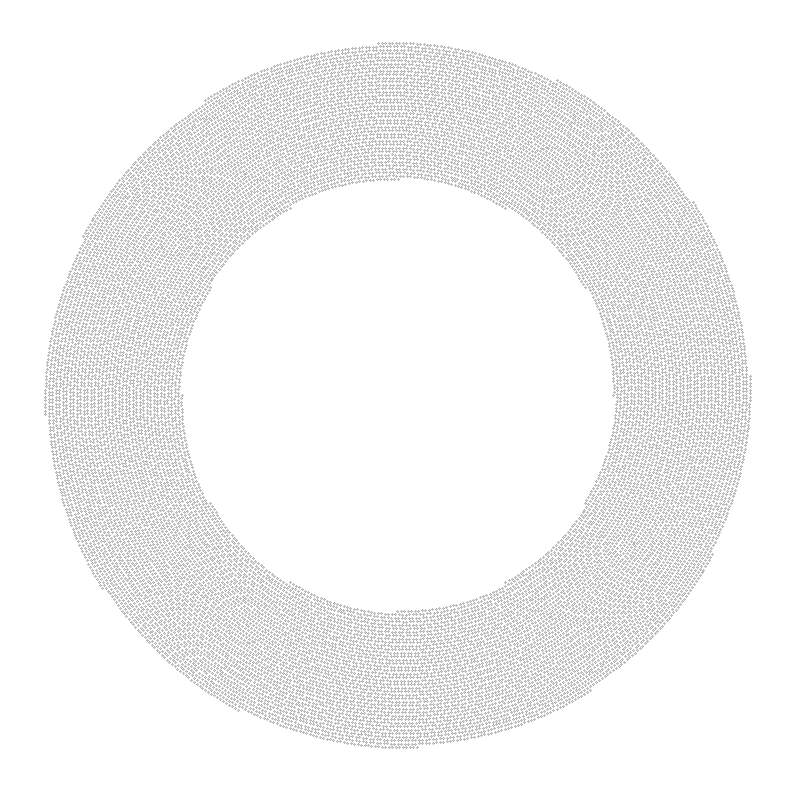

In [7]:
disk_diameter = 50
pinhole_pitch = 0.253
lines_number = 36

disk = NipkowDiskYokogawa(min_pinholes=20000,
                          r_in_mm=disk_diameter/2 - pinhole_pitch*lines_number,
                          r_out_mm=disk_diameter/2,
                          sectors=12,
                          pitch_mm=pinhole_pitch)
disk.plot()

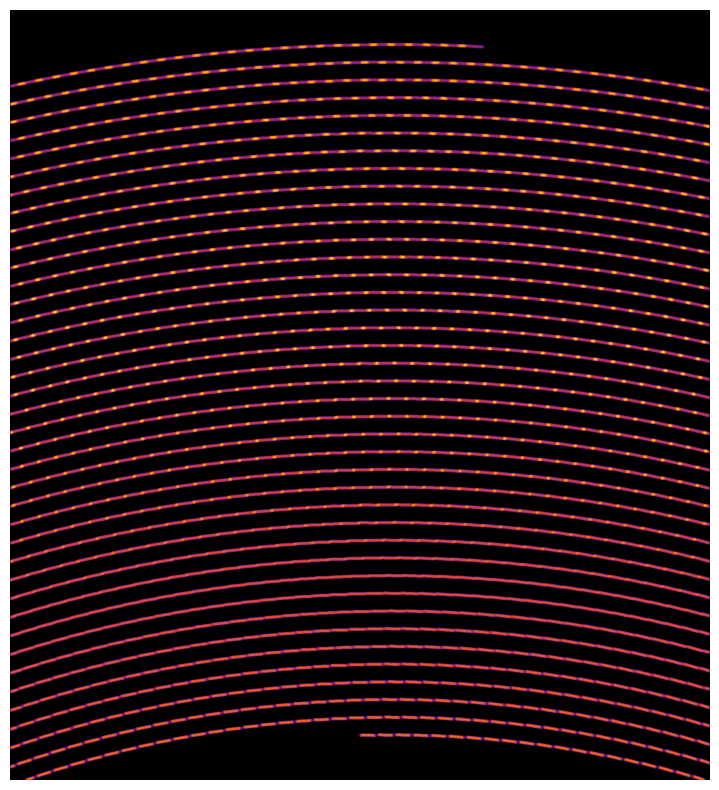

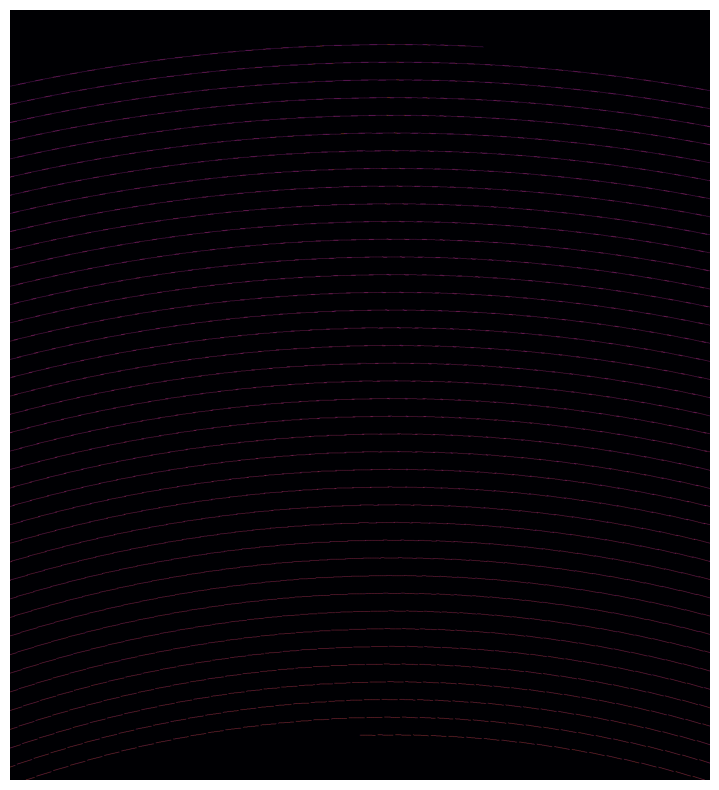

In [8]:
sim = CSUSimulator(disk,
                   fov_center_mm=(0.0, -20.5),
                   fov_size_mm=(11.0, 10.0),
                   camera_res=2000)
simulated_single, hist_single = sim.simulate_exposure(rpm=1800, exposure_sec=7.5e-5, pinhole_diam_mm=0.05, return_raw=True)

sim.plot_result(simulated_single)  # simulated image with applied PSF
sim.plot_result(hist_single)       # accumulated image of pinholes travel without PSF

In [ ]:
from skimage.io import imsave
imsave('disk_sim/simulated_img.tiff', simulated_single.astype(np.uint16))
imsave('disk_sim/simulated_hist.tiff', hist_single.astype(np.uint16))

/home/wisstock/miniconda3/envs/napari-dev/lib/python3.13/site-packages/skimage/_shared/utils.py:328: UserWarning: disk_sim/simulated_img.tiff is a low contrast image
  return func(*args, **kwargs)


In [9]:
simulated_single.shape

(2000, 1818)

## Spectral imaging phases modeling

### Demo phase imaging

Pulse exposure: 75 us, exposure cycle duration: 2.78 ms, total exposure: 333.33 ms, RPM: 1800


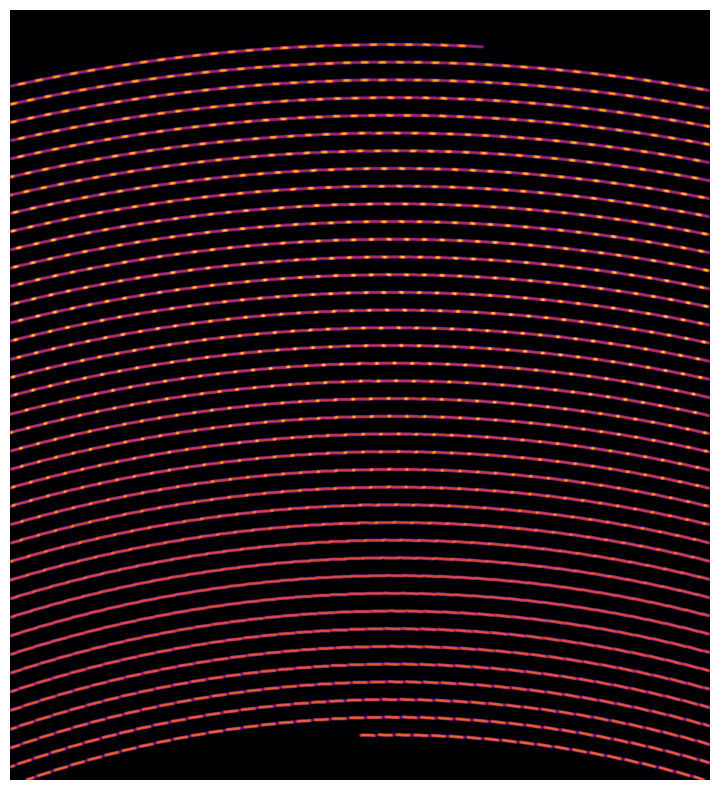

In [8]:
rpm = 1800
pulse_exp = 7.5e-5
cycle_time = 1/(rpm/60) / 12

accumulation_cycles = 10
total_exp = 1/(rpm/60) * accumulation_cycles

print(f'Pulse exposure: {(pulse_exp * 1e6):.0f} us, exposure cycle duration: {(cycle_time * 1000):.2f} ms, total exposure: {(total_exp * 1000):.2f} ms, RPM: {rpm}')

simulated_pulse = sim.simulate_pulse_exposure(rpm=rpm,
                                              exposure_sec=pulse_exp,
                                              gap_sec=cycle_time - pulse_exp,
                                              total_sec=total_exp,
                                              phase_shift=0.0,
                                              pinhole_diam_mm=0.05,
                                              return_raw=False)
sim.plot_result(simulated_pulse)

In [9]:
sim.animate_pulse_exposure(rpm=rpm,
                           rotations=2.0,
                           exposure_sec=pulse_exp,
                           gap_sec=cycle_time - pulse_exp,
                           phase_shift=0.0,
                           pinhole_diam_mm=0.05,
                           filename="phase_simulation.gif",
                           fps=5)

### Real phase imaging

Pulse exposure: 75 us, exposure cycle duration: 3.00 ms, total exposure: 200.00 ms, RPM: 1666.65


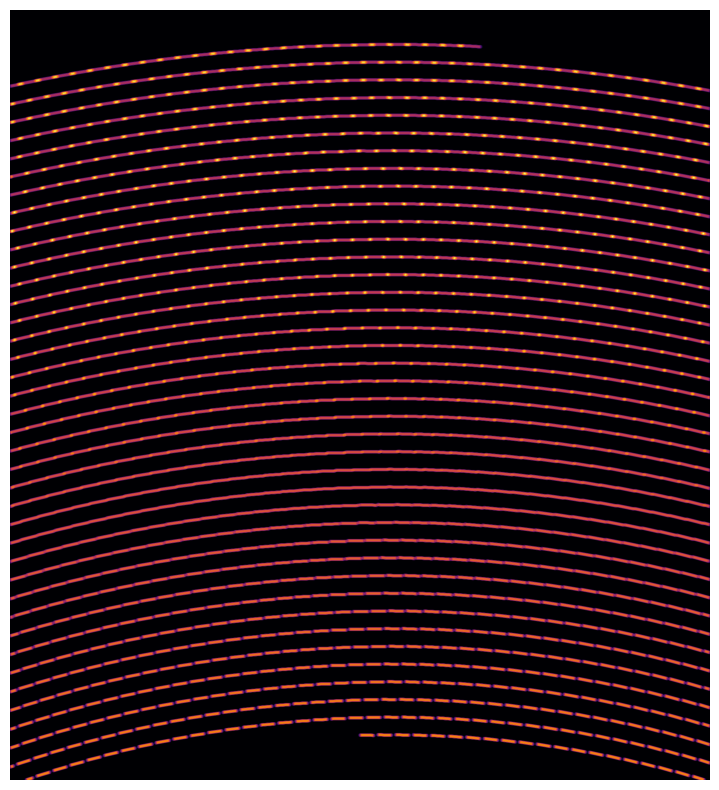

In [10]:
rpm = 55.555/2 * 60
pulse_exp = 7.5e-5
cycle_time = 3e-3
total_exp = 0.2

print(f'Pulse exposure: {(pulse_exp * 1e6):.0f} us, exposure cycle duration: {(cycle_time * 1000):.2f} ms, total exposure: {(total_exp * 1000):.2f} ms, RPM: {rpm}')

simulated_pulse_real = sim.simulate_pulse_exposure(rpm=rpm,
                                                   exposure_sec=pulse_exp,
                                                   gap_sec=cycle_time - pulse_exp,
                                                   total_sec=total_exp,
                                                   phase_shift=0.0,
                                                   pinhole_diam_mm=0.05,
                                                   return_raw=False)
sim.plot_result(simulated_pulse_real)

In [11]:
sim.animate_pulse_exposure(rpm=rpm,
                           rotations=5.0,
                           exposure_sec=pulse_exp,
                           gap_sec=cycle_time - pulse_exp,
                           phase_shift=0.0,
                           pinhole_diam_mm=0.05,
                           filename="phase_simulation_real.gif",
                           fps=5)

#### Whole phase set imaging

In [15]:
phase_delay = np.arange(0, 40) * pulse_exp  # simulate different initial phase shifts
phase_series = []

for one_phase in phase_delay:
    sim_phase = sim.simulate_pulse_exposure(rpm=rpm,
                                           exposure_sec=pulse_exp,
                                           gap_sec=cycle_time - pulse_exp,
                                           total_sec=total_exp,
                                           phase_shift=one_phase,
                                           pinhole_diam_mm=0.05,
                                           return_raw=False)
    phase_series.append(sim_phase)
phase_series = np.array(phase_series)

In [ ]:
# from skimage import io
# io.imsave("phase_series.tif", (phase_series / np.max(phase_series) * 65535).astype(np.uint16))

(np.float64(-0.5), np.float64(1817.5), np.float64(1999.5), np.float64(-0.5))

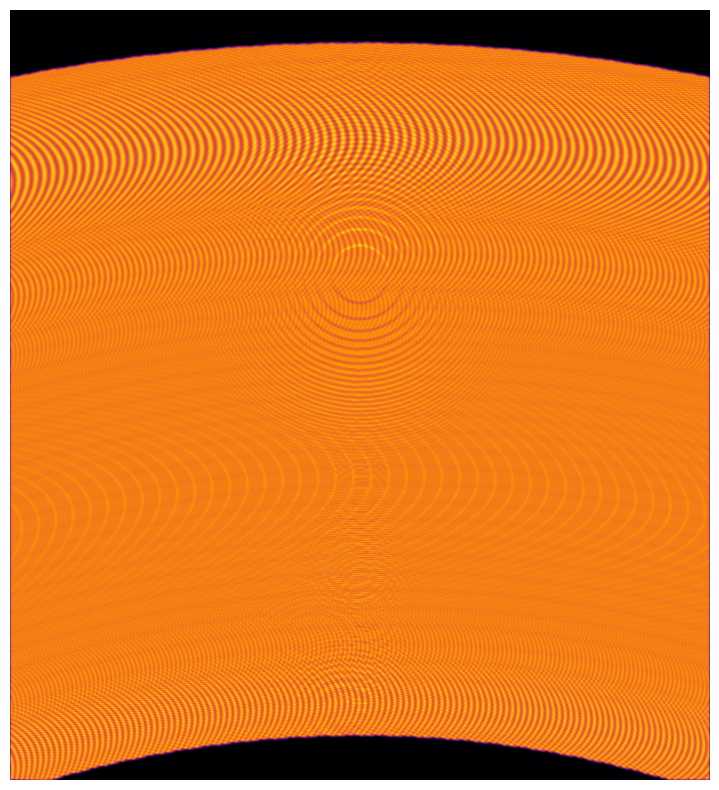

In [40]:
plt.figure(figsize=(10, 10))
plt.imshow(np.sum(phase_series[0:-1:2], axis=0), cmap='inferno')
plt.axis('off')

## SIM pattern modeling

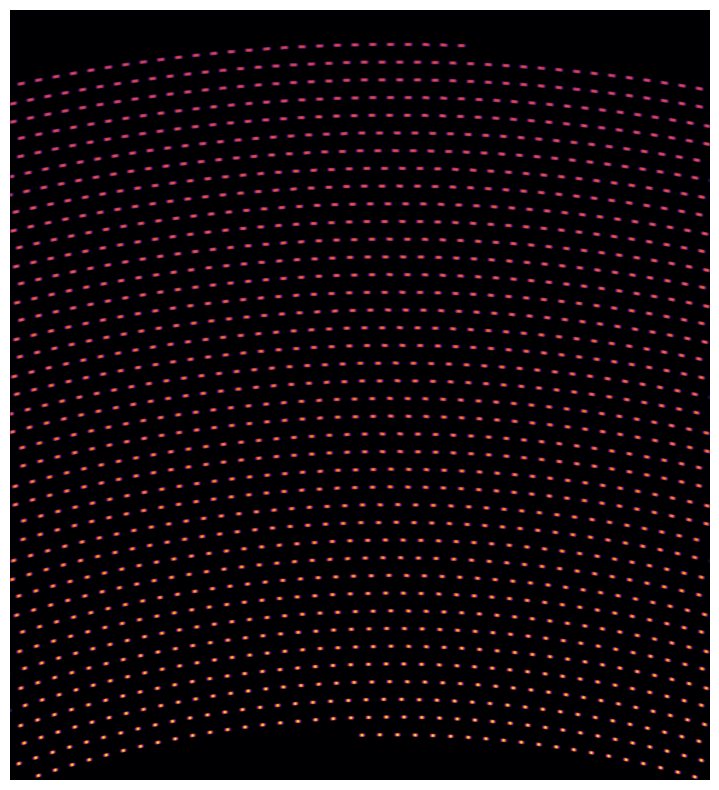

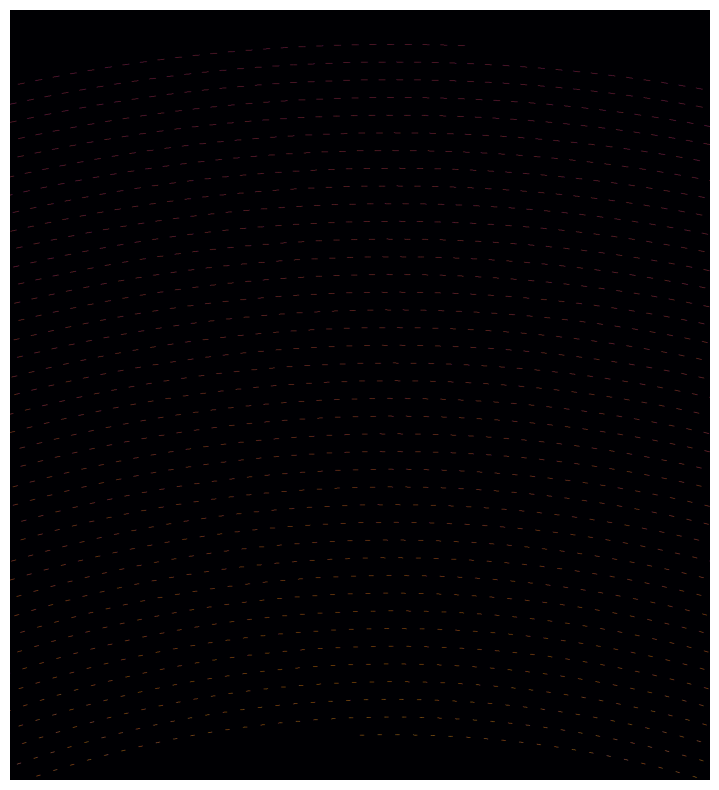

In [161]:
sim_sim = CSUSimulator(disk,
                       fov_center_mm=(0.0, -20.5),
                       fov_size_mm=(11.0, 10.0),
                       camera_res=2000)
simulated_sim, hist_sim = sim_sim.simulate_exposure(rpm=1800, exposure_sec=2e-5, pinhole_diam_mm=0.05, return_raw=True)
sim_sim.plot_result(simulated_sim)
sim_sim.plot_result(hist_sim)

Pulse exposure: 20 us, exposure cycle duration: 1.39 ms, total exposure: 166.67 ms, RPM: 1800


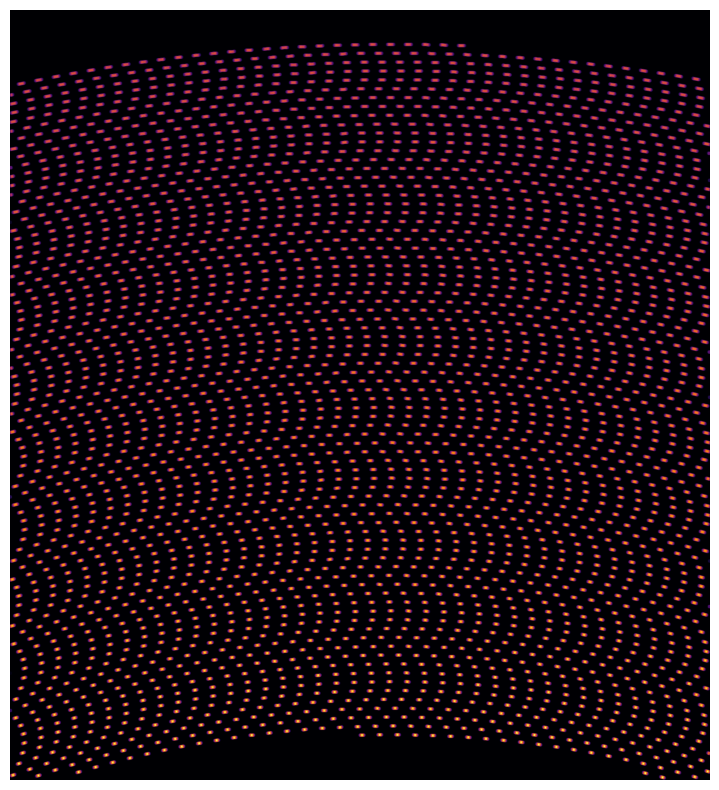

In [192]:
rpm = 1800
pulse_exp = 2e-5
cycle_time = 1/(rpm/60) / 24

accumulation_cycles = 5
total_exp = 1/(rpm/60) * accumulation_cycles

pattern_shift = cycle_time

print(f'Pulse exposure: {(pulse_exp * 1e6):.0f} us, exposure cycle duration: {(cycle_time * 1000):.2f} ms, total exposure: {(total_exp * 1000):.2f} ms, RPM: {rpm}')

simulated_pulse = sim_sim.simulate_pulse_exposure(rpm=rpm,
                                                  exposure_sec=pulse_exp,
                                                  gap_sec=cycle_time - pulse_exp,
                                                  total_sec=total_exp,
                                                  phase_shift=cycle_time*0,
                                                  pinhole_diam_mm=0.05,
                                                  return_raw=False)
sim.plot_result(simulated_pulse)